In [1]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = os.getcwd()
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy import stats
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import plot_correlations
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist


random.seed(42)
np.random.seed(42)

PLOT_DATA_STORE_PATH = setup_environment(LOCSCALE_2_SCRIPTS_PATH)

Data already exists. Skipping download.
Sourcing data from: /home/abharadwaj1/papers/publications/2025_LocScale-2.0/LocScale2.0_NComms_2026_plotData
--------------------------------------------------------------------------------


## Supplementary 2 b

In [2]:
# neighborhood_correlation_radius_json = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/outputs/supplementary_2/neighborhood_correlation/neighborhood_correlation_data.json"

# correlation_data = pd.read_json(neighborhood_correlation_radius_json).T
# atomic_correlation_df = correlation_data["atomic"]

# atomic_correlation_data = []
# for radius in ["radius_2", "radius_10"]:
#     individual_bfactors = atomic_correlation_df[radius]["individual_bfactors"]
#     neighborhood_bfactors = atomic_correlation_df[radius]["neighborhood_bfactors"]
#     for i, n in zip(individual_bfactors, neighborhood_bfactors):
#         atomic_correlation_data.append({
#             "radius": radius,
#             "individual_bfactor": i,
#             "neighborhood_bfactor": n
#         })

# atomic_correlation_data = pd.DataFrame(atomic_correlation_data)

atomic_correlation_data_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_b_neighborhood_correlation_atomic.csv")
#atomic_correlation_data.to_csv(atomic_correlation_data_save_path, index=False)

atomic_correlation_data = pd.read_csv(atomic_correlation_data_save_path)

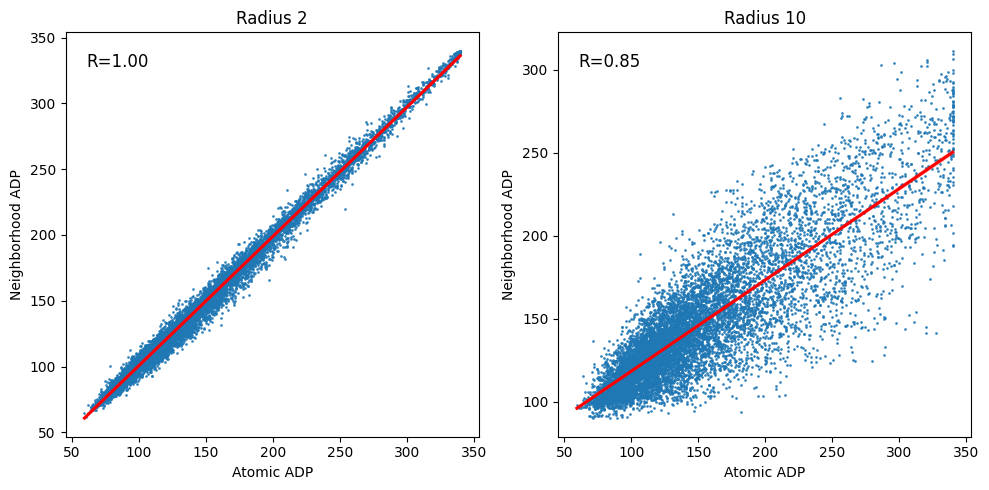

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.regplot(data=atomic_correlation_data[atomic_correlation_data["radius"] == "radius_2"],
            x="individual_bfactor", y="neighborhood_bfactor", ax=ax[0], scatter_kws={"s": 1}, line_kws={"color": "red"})
sns.regplot(data=atomic_correlation_data[atomic_correlation_data["radius"] == "radius_10"],
            x="individual_bfactor", y="neighborhood_bfactor", ax=ax[1], scatter_kws={"s": 1}, line_kws={"color": "red"})
pearson_r_2 = stats.pearsonr(atomic_correlation_data[atomic_correlation_data["radius"] == "radius_2"]["individual_bfactor"],
                                atomic_correlation_data[atomic_correlation_data["radius"] == "radius_2"]["neighborhood_bfactor"])[0]
pearson_r_10 = stats.pearsonr(atomic_correlation_data[atomic_correlation_data["radius"] == "radius_10"]["individual_bfactor"],
                                atomic_correlation_data[atomic_correlation_data["radius"] == "radius_10"]["neighborhood_bfactor"])[0]

text_str_2 = f"R={pearson_r_2:.2f}"
text_str_10 = f"R={pearson_r_10:.2f}"
ax[0].set_title("Radius 2")
ax[1].set_title("Radius 10")
ax[0].set_xlabel("Atomic ADP")
ax[0].set_ylabel("Neighborhood ADP")
ax[1].set_xlabel("Atomic ADP")
ax[1].set_ylabel("Neighborhood ADP")
ax[0].text(0.05, 0.95, text_str_2, transform=ax[0].transAxes, fontsize=12,
           verticalalignment='top')
ax[1].text(0.05, 0.95, text_str_10, transform=ax[1].transAxes, fontsize=12,
            verticalalignment='top')
plt.tight_layout()

In [4]:
correlation_data_file_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/outputs/supplementary_2/neighborhood_correlation/neighborhood_radius_vs_correlation_values.json"

correlation_data = pd.read_json(correlation_data_file_path)
correlation_data.head()

,radii,atomic,restrained_pseudomodel,unrestrained_pseudomodel,restrained_pseudomodel_ordered,restrained_pseudomodel_disordered,unrestrained_pseudomodel_ordered,unrestrained_pseudomodel_disordered
0,1,1.000000,0.999862,0.977655,0.999677,0.999779,0.959845,0.992263
1,2,0.995677,0.997302,0.850340,0.997219,0.992477,0.776134,0.863655
2,3,0.979417,0.997480,0.736923,0.997417,0.993487,0.630752,0.702290
3,4,0.960457,0.965353,0.675381,0.978940,0.893456,0.566863,0.581677
4,5,0.937676,0.933850,0.647401,0.961188,0.784223,0.549950,0.498005


In [5]:
refinement_method = ["restrained", "unrestrained", "atomic"]
models = ["atomic_model", "pseudomodel"]
region = ["ordered", "disordered", "all"]

radii = correlation_data["radii"].values
atomic_correlation = correlation_data["atomic"].values
restrained_pseudo_correlation = correlation_data["restrained_pseudomodel"].values
unrestrained_pseudo_correlation = correlation_data["unrestrained_pseudomodel"].values
ordered_pseudomodel_correlation = correlation_data["restrained_pseudomodel_ordered"].values
disordered_pseudomodel_correlation = correlation_data["restrained_pseudomodel_disordered"].values
unrestrained_ordered_pseudomodel_correlation = correlation_data["unrestrained_pseudomodel_ordered"].values
unrestrained_disordered_pseudomodel_correlation = correlation_data["unrestrained_pseudomodel_disordered"].values

correlation_data_long = []
for i, r in enumerate(radii):
    correlation_data_long.append({
        "radius": r,
        "correlation": atomic_correlation[i],
        "model": "atomic_model",
        "refinement": "atomic",
        "region": "all"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": restrained_pseudo_correlation[i],
        "model": "pseudomodel",
        "refinement": "restrained",
        "region": "all"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": unrestrained_pseudo_correlation[i],
        "model": "pseudomodel",
        "refinement": "unrestrained",
        "region": "all"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": ordered_pseudomodel_correlation[i],
        "model": "pseudomodel",
        "refinement": "restrained",
        "region": "ordered"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": disordered_pseudomodel_correlation[i],
        "model": "pseudomodel",
        "refinement": "restrained",
        "region": "disordered"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": unrestrained_ordered_pseudomodel_correlation[i],
        "model": "pseudomodel",
        "refinement": "unrestrained",
        "region": "ordered"
    })
    correlation_data_long.append({
        "radius": r,
        "correlation": unrestrained_disordered_pseudomodel_correlation[i],
        "model": "pseudomodel",
        "refinement": "unrestrained",
        "region": "disordered"
    })


correlation_data_long = pd.DataFrame(correlation_data_long)

correlation_data_long_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_c_neighborhood_radius_vs_correlation_values.csv")
correlation_data_long.to_csv(correlation_data_long_save_path, index=False)

correlation_data_long = pd.read_csv(correlation_data_long_save_path)

In [6]:
correlation_data_long.head()

,radius,correlation,model,refinement,region
0,1,1.000000,atomic_model,atomic,all
1,1,0.999862,pseudomodel,restrained,all
2,1,0.977655,pseudomodel,unrestrained,all
3,1,0.999677,pseudomodel,restrained,ordered
4,1,0.999779,pseudomodel,restrained,disordered


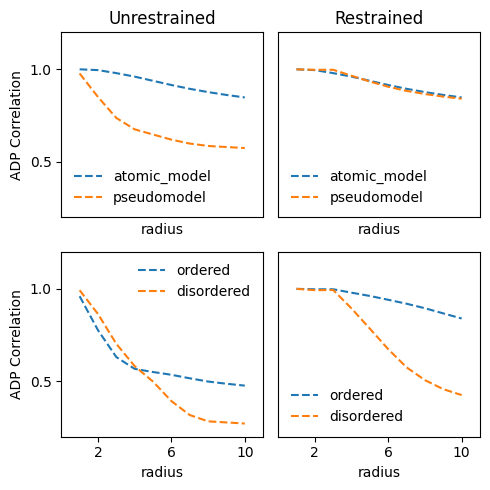

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5))
x_ticks = [2, 6, 10]
y_ticks = [0.5, 1]
x_lim = [ 0, 11]
y_lim = [0.2, 1.2]
plot_data_1 = correlation_data_long[(correlation_data_long["model"] == "atomic_model") | \
                                        (correlation_data_long["model"] == "pseudomodel") & \
                                        (
                                            (correlation_data_long["refinement"] == "unrestrained") |
                                            (correlation_data_long["refinement"] == "atomic")
                                        ) & 
                                        ((correlation_data_long["region"] == "all"))
                                        ]
plot_data_2 = correlation_data_long[(correlation_data_long["model"] == "atomic_model") | \
                                        (correlation_data_long["model"] == "pseudomodel") & \
                                        (
                                            (correlation_data_long["refinement"] == "restrained") |
                                            (correlation_data_long["refinement"] == "atomic")
                                        ) &
                                        ((correlation_data_long["region"] == "all"))
                                        ]

plot_data_3 = correlation_data_long[(correlation_data_long["model"] == "pseudomodel") & \
                                    (     
                                        (correlation_data_long["region"] == "ordered") | \
                                        (correlation_data_long["region"] == "disordered") \
                                    ) & \
                                        (correlation_data_long["refinement"] == "unrestrained")]
plot_data_4 = correlation_data_long[(correlation_data_long["model"] == "pseudomodel") & \
                                    ( 
                                        (correlation_data_long["region"] == "ordered") | \
                                        (correlation_data_long["region"] == "disordered") \
                                    ) & \
                                        (correlation_data_long["refinement"] == "restrained")]

ax[0, 0].set_title("Unrestrained")
sns.lineplot(data=plot_data_1, x="radius", y="correlation", hue="model", ax=ax[0, 0], linestyle="--")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks(y_ticks)
ax[0, 0].set_ylim(y_lim)
ax[0, 0].set_xlim(x_lim)
ax[0, 0].set_ylabel("ADP Correlation")
# remove box around legend
ax[0, 0].legend(frameon=False)
sns.lineplot(data=plot_data_2, x="radius", y="correlation", hue="model", ax=ax[0, 1], linestyle="--")
ax[0, 1].set_title("Restrained")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])
ax[0, 1].set_ylim(y_lim)
ax[0, 1].set_xlim(x_lim)
ax[0, 1].set_ylabel("")
ax[0, 1].legend(frameon=False)
sns.lineplot(data=plot_data_3, x="radius", y="correlation", hue="region", ax=ax[1, 0], linestyle="--")
ax[1, 0].set_xticks(x_ticks)
ax[1, 0].set_yticks(y_ticks)
ax[1, 0].set_ylim(y_lim)
ax[1, 0].set_xlim(x_lim)
ax[1, 0].set_ylabel("ADP Correlation")
ax[1, 0].legend(frameon=False)
sns.lineplot(data=plot_data_4, x="radius", y="correlation", hue="region", ax=ax[1, 1], linestyle="--")
ax[1, 1].set_xticks(x_ticks)
ax[1, 1].set_yticks([])
ax[1, 1].set_ylim(y_lim)
ax[1, 1].set_xlim(x_lim)
ax[1, 1].set_ylabel("")
ax[1, 1].legend(frameon=False)
# set common x label
fig.tight_layout()




## Supplementary 3 d

In [8]:
# import pickle
# atomic_v_pseudoatomic_adp_correlation_pickle = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/structured_data/supplementary_2a/emd_3061_bfactor_distribution_data.pickle"
# with open(atomic_v_pseudoatomic_adp_correlation_pickle, 'rb') as handle:
#     atomic_v_pseudoatomic_adp_correlation = pickle.load(handle)
    

In [9]:
# pseudo_bfactors = atomic_v_pseudoatomic_adp_correlation["pseudo_bfactors"]
# atomic_bfactors = atomic_v_pseudoatomic_adp_correlation["atomic_bfactors"]

# bfactors_data = []
# for a, p in zip(atomic_bfactors, pseudo_bfactors):
#     bfactors_data.append({
#         "atomic_bfactor": a,
#         "pseudoatomic_bfactor": p
#     })
# bfactors_data = pd.DataFrame(bfactors_data, columns=["atomic_bfactor", "pseudoatomic_bfactor"])
bfactors_data_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_d_atomic_vs_pseudoatomic_bfactor_distribution_3061.csv")
# bfactors_data.to_csv(bfactors_data_save_path, index=False)
bfactors_data = pd.read_csv(bfactors_data_save_path)




<Figure size 1181.1x1181.1 with 0 Axes>

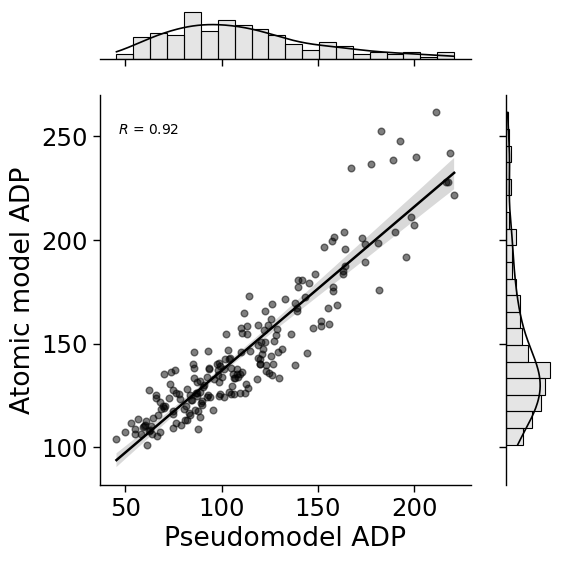

In [10]:
from scripts.utils.plot_utils import  get_2d_jointplot_with_text

get_2d_jointplot_with_text(bfactors_data["pseudoatomic_bfactor"], bfactors_data["atomic_bfactor"], \
            "Pseudomodel ADP", "Atomic model ADP", \
            figsize_mm=(50,50), save_path=None)

## Supplementary 3 e

In [11]:
# adp_correlation_all_data_pickle = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/structured_data/supplementary_2/ADP_correlation_curves_all_emdb.pickle"

# adp_correlation_all_data = pd.read_pickle(adp_correlation_all_data_pickle)
# adp_correlation_curves_pseudomodel_restrained = adp_correlation_all_data["adp_correlation_curves_pseudomodel_restrained"]
# adp_correlation_curves_pseudomodel_unrestrained = adp_correlation_all_data["adp_correlation_curves_pseudomodel_unrestrained"]
# adp_correlation_curves_atomic_model = adp_correlation_all_data["adp_correlation_curves_atomic_model"]


In [12]:
# from scipy.stats import pearsonr
# radii = [float(x) for x in list(adp_correlation_curves_pseudomodel_restrained["7573_6crv"].keys())]

# # Convert to long format
# correlation_curve_data_long = []
# for emd_id in adp_correlation_curves_pseudomodel_restrained.keys():
#     neighborhood_correlation_curves_restrained = adp_correlation_curves_pseudomodel_restrained[emd_id]
#     neighborhood_correlation_curves_unrestrained = adp_correlation_curves_pseudomodel_unrestrained[emd_id]
#     neighborhood_correlation_curves_atomic = adp_correlation_curves_atomic_model[emd_id]

#     correlations_restrained = [x[2][0] for x in neighborhood_correlation_curves_restrained.values()]
#     correlations_unrestrained = [x[2][0] for x in neighborhood_correlation_curves_unrestrained.values()]
#     correlations_atomic = [x[2][0] for x in neighborhood_correlation_curves_atomic.values()]

#     pearson_r_restrained = pearsonr(correlations_atomic, correlations_restrained)[0]
#     pearson_r_unrestrained = pearsonr(correlations_atomic, correlations_unrestrained)[0]

#     for radius in radii:
#         correlation_curve_data_long.append({
#             "emd_id": emd_id,
#             "radius": radius,
#             "correlation": adp_correlation_curves_atomic_model[emd_id][radius][2][0],
#             "refinement": "atomic",
#             "pearson_r": 1,
#         })
#         correlation_curve_data_long.append({
#             "emd_id": emd_id,
#             "radius": radius,
#             "correlation": adp_correlation_curves_pseudomodel_restrained[emd_id][radius][2][0],
#             "refinement": "restrained",
#             "pearson_r": pearson_r_restrained,
#         })
#         correlation_curve_data_long.append({
#             "emd_id": emd_id,
#             "radius": radius,
#             "correlation": adp_correlation_curves_pseudomodel_unrestrained[emd_id][radius][2][0],
#             "refinement": "unrestrained",
#             "pearson_r": pearson_r_unrestrained,
#         })
# correlation_curve_data_long = pd.DataFrame(correlation_curve_data_long)

correlation_curve_data_long_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_e_neighborhood_radius_vs_correlation_values_individual_emdb.csv")
#correlation_curve_data_long.to_csv(correlation_curve_data_long_save_path, index=True)

correlation_curve_data_long = pd.read_csv(correlation_curve_data_long_save_path)

# Compute pearson_r 

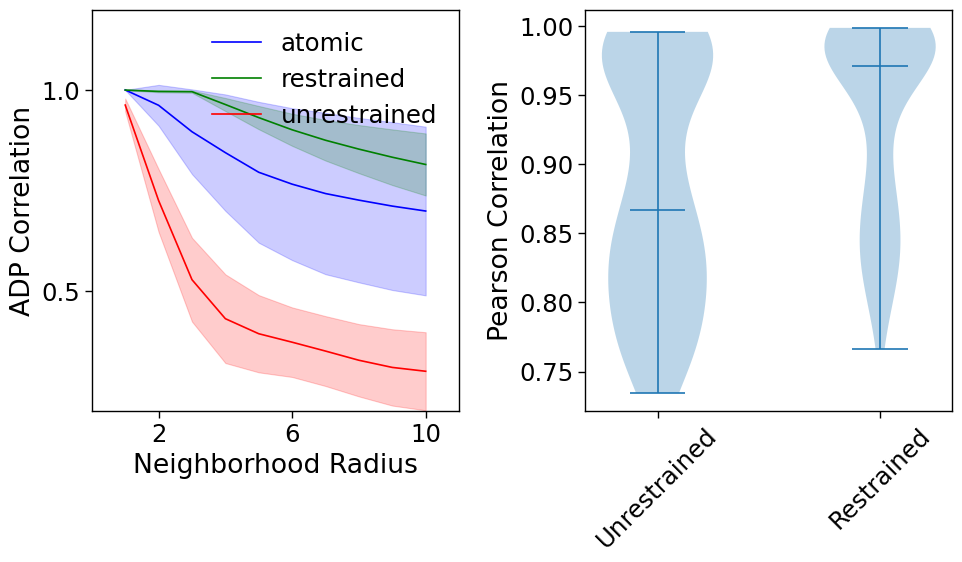

In [13]:
# Filter out atomic for pearson correlation plot and remove nans
pearson_correlation_data = correlation_curve_data_long[correlation_curve_data_long["refinement"] != "atomic"]
pearson_correlation_data = pearson_correlation_data.dropna(subset=["pearson_r"])

palette = {"atomic": "blue", "restrained": "green", "unrestrained": "red"}
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
sns.lineplot(data=correlation_curve_data_long, x="radius", y="correlation", hue="refinement", errorbar=("sd"), palette=palette, ax=ax[0])
ax[0].set_xticks([2, 6, 10])
ax[0].set_yticks([0.5, 1])
ax[0].set_ylim([0.2, 1.2])
ax[0].set_xlim([0, 11])
ax[0].legend(frameon=False)
ax[0].set_xlabel("Neighborhood Radius")
ax[0].set_ylabel("ADP Correlation")

pearson_unrestrained = pearson_correlation_data[pearson_correlation_data["refinement"] == "unrestrained"]["pearson_r"].values
pearson_restrained = pearson_correlation_data[pearson_correlation_data["refinement"] == "restrained"]["pearson_r"].values

pearson_unrestrained = np.unique(pearson_unrestrained[~np.isnan(pearson_unrestrained)])
pearson_restrained = np.unique(pearson_restrained[~np.isnan(pearson_restrained)])

ax[1].violinplot([pearson_unrestrained, pearson_restrained], \
                showmeans=False, showmedians=True)
ax[1].set_ylabel("Pearson Correlation")
ax[1].set_xticks([1, 2], ["Unrestrained", "Restrained"], rotation=45)



fig.tight_layout()

In [14]:
# Run permutation test on pearson correlation values between restrained and unrestrained
from scipy.stats import permutation_test
def statistic(x, y):
    return np.median(x) - np.median(y)
res = permutation_test((pearson_unrestrained, pearson_restrained), statistic,
                       n_resamples=10000, random_state=42)

print(f"Statistical test:")
print(f"Median Pearson correlation (unrestrained): {np.median(pearson_unrestrained)}")
print(f"Median Pearson correlation (restrained): {np.median(pearson_restrained)}")
print(f"P-value: {res.pvalue}")


Statistical test:
Median Pearson correlation (unrestrained): 0.8666876946902123
Median Pearson correlation (restrained): 0.9708503145981204
P-value: 0.0005999400059994001


## Supplementary 3 i

In [15]:
# ks_distances_csv = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/structured_data/supplementary_2a/ks_distances.csv"

# data = pd.read_csv(ks_distances_csv)

# ks_distance_pseudo_values = data["ks_distance_pseudo_values"]
# ks_distance_atomic_values = data["ks_distance_atomic_values"]
# ks_pvalues_pseudo_values = data["ks_pvalues_pseudo_values"]
# ks_pvalues_atomic_values = data["ks_pvalues_atomic_values"]
# emdb_pdbs = data["EMDB_PDB_ids_present"]

# ks_distance_data_long = []
# for emdb_pdb in emdb_pdbs:
#     ks_distance_data_long.append({
#         "emdb_pdb": emdb_pdb,
#         "ks_distance": data[data["EMDB_PDB_ids_present"] == emdb_pdb]["ks_distance_atomic_values"].values[0],
#         "model": "atomic_model",
#         "pvalue" : data[data["EMDB_PDB_ids_present"] == emdb_pdb]["ks_pvalues_atomic_values"].values[0],
#     })
#     ks_distance_data_long.append({
#         "emdb_pdb": emdb_pdb,
#         "ks_distance": data[data["EMDB_PDB_ids_present"] == emdb_pdb]["ks_distance_pseudo_values"].values[0],
#         "model": "pseudomodel",
#         "pvalue" : data[data["EMDB_PDB_ids_present"] == emdb_pdb]["ks_pvalues_pseudo_values"].values[0],
#     })

# ks_distance_data_long = pd.DataFrame(ks_distance_data_long)

ks_distance_data_long_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_i_ks_distance_values_individual_emdb.csv")
# ks_distance_data_long.to_csv(ks_distance_data_long_save_path, index=True)

ks_distance_data_long = pd.read_csv(ks_distance_data_long_save_path)

Text(0.5, 23.91666666666665, '')

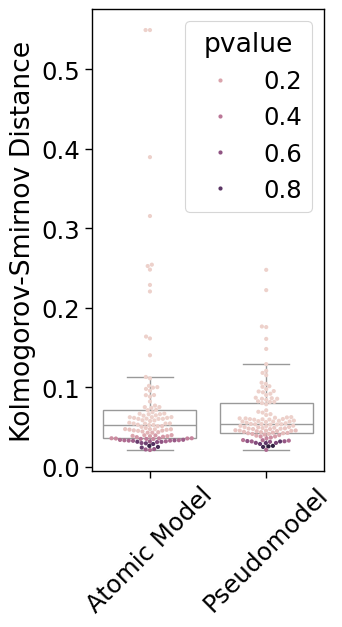

In [16]:

fig, ax = plt.subplots(1, 1, figsize=(3, 6))
sns.boxplot(data=ks_distance_data_long, x="model", y="ks_distance", color="white", showfliers=False, ax=ax);
sns.swarmplot(data=ks_distance_data_long, x="model", y="ks_distance", hue="pvalue", dodge=False, size=3, ax=ax);
ax.set_xticks([0, 1], ["Atomic Model", "Pseudomodel"], rotation=45);
ax.set_ylabel("Kolmogorov-Smirnov Distance");
ax.set_xlabel("")

## Supplementary 3 j

In [17]:
# def emdb_to_pdb(emdb_id):
#     import requests    
#     url = f"https://www.ebi.ac.uk/emdb/api/entry/{emdb_id}"
#     response = requests.get(url)
#     data = response.json()
#     try:
#         pdb_id = data["crossreferences"]["pdb_list"]["pdb_reference"][0]["pdb_id"]

#         return pdb_id    
#     except (KeyError, IndexError):
#         print(f"No PDB ID found for EMDB ID {emdb_id}")
#         return "none"

In [18]:
# import glob
# import tobvalid 
# import json
# json_pattern = os.path.join(
#         "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data",
#         "structured_data", "supplementary_2a", "tobvalid_analysis",
#         "albe_results",
#         #"pseudomodel",
#         "PDB_*_unrefined_shifted_servalcat_refined_servalcat_refined_mixture.json",
#         #"emd_*_FDR_confidence_final_gradient_pseudomodel_proper_element_composition_averaged_mixture.json"
#     )
# json_files = glob.glob(json_pattern)
# if not json_files:
#     raise FileNotFoundError(f"No JSON files found matching: {json_pattern}")

# alphas_first_mode = []
# sqrt_betas_first_mode = []
# alphas_second_mode = []
# sqrt_betas_second_mode = []
# pdb_ids_list = []
# print("Length of json_files:", len(json_files))
# for jf in json_files:
#     with open(jf, 'r') as f:
#         data = json.load(f)

#     alphas_first_mode.append(data["Alpha"][0])
#     sqrt_betas_first_mode.append(np.sqrt(data["Beta"][0]))
#     alphas_second_mode.append(data["Alpha"][1])
#     sqrt_betas_second_mode.append(np.sqrt(data["Beta"][1]))
#     emdb_id = os.path.basename(jf).split("_")[1]
#     pdb_ids_list.append(emdb_id)
#     #has_membrane.append(emdb_contains_membrane(emdb_id))

# json_pattern_pseudomodel = os.path.join(
#         "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data",
#         "structured_data", "supplementary_2a", "tobvalid_analysis",
#         "albe_results",
#         "pseudomodel",
#         #"PDB_*_unrefined_shifted_servalcat_refined_servalcat_refined_mixture.json",
#         "emd_*_FDR_confidence_final_gradient_pseudomodel_proper_element_composition_averaged_mixture.json"
#     )

# json_files_pseudomodel = glob.glob(json_pattern_pseudomodel)
# if not json_files_pseudomodel:
#     raise FileNotFoundError(f"No JSON files found matching: {json_pattern_pseudomodel}")


# alphas_first_mode_pseudomodel = []
# sqrt_betas_first_mode_pseudomodel = []
# alphas_second_mode_pseudomodel = []
# sqrt_betas_second_mode_pseudomodel = []

# for jf in json_files_pseudomodel:
#     with open(jf, 'r') as f:
#         data = json.load(f)
#     emdb_id = os.path.basename(jf).split("_")[1]
#     pdb_id = emdb_to_pdb(emdb_id)
#     if pdb_id not in pdb_ids_list:
#         continue
    

#     alphas_first_mode_pseudomodel.append(data["Alpha"][0])
#     sqrt_betas_first_mode_pseudomodel.append(np.sqrt(data["Beta"][0]))
#     alphas_second_mode_pseudomodel.append(data["Alpha"][1])
#     sqrt_betas_second_mode_pseudomodel.append(np.sqrt(data["Beta"][1]))
    
#     #has_membrane.append(emdb_contains_membrane(emdb_id))
                                   
# print("Length of json_files_pseudomodel:", len(sqrt_betas_second_mode_pseudomodel))
# # — Load 2D KDE and grid from tobvalid templates
# d = os.path.dirname(tobvalid.__file__)
# xx = np.load(os.path.join(d, "templates", "xx.npy"))
# yy = np.load(os.path.join(d, "templates", "yy.npy"))
# kde = np.load(os.path.join(d, "templates", "albe_kde.npy"))


In [19]:
# # convert to dataframe long 
# alpha_beta_data_long = []
# for i, pdb_id in enumerate(pdb_ids_list):
#     alpha_beta_data_long.append({
#         "pdb_id": pdb_id,
#         "alpha": alphas_first_mode[i],
#         "sqrt_beta": sqrt_betas_first_mode[i],
#         "mode": "first",
#         "model": "atomic_model"
#     })
#     alpha_beta_data_long.append({
#         "pdb_id": pdb_id,
#         "alpha": alphas_second_mode[i],
#         "sqrt_beta": sqrt_betas_second_mode[i],
#         "mode": "second",
#         "model": "atomic_model"
#     })
#     alpha_beta_data_long.append({
#         "pdb_id": pdb_id,
#         "alpha": alphas_first_mode_pseudomodel[i],
#         "sqrt_beta": sqrt_betas_first_mode_pseudomodel[i],
#         "mode": "first",
#         "model": "pseudomodel"
#     })
#     alpha_beta_data_long.append({
#         "pdb_id": pdb_id,
#         "alpha": alphas_second_mode_pseudomodel[i],
#         "sqrt_beta": sqrt_betas_second_mode_pseudomodel[i],
#         "mode": "second",
#         "model": "pseudomodel"
#     })
# alpha_beta_data_long = pd.DataFrame(alpha_beta_data_long)

alpha_beta_data_long_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s3_j_albe_parameters_individual_emdb.csv")
#alpha_beta_data_long.to_csv(alpha_beta_data_long_save_path, index=True)
alpha_beta_data_long = pd.read_csv(alpha_beta_data_long_save_path)

# save kde, xx, yy as npy files 
kde_save_path = os.path.join(PLOT_DATA_STORE_PATH, "tobvalid_kde.npy")
xx_save_path = os.path.join(PLOT_DATA_STORE_PATH, "tobvalid_xx.npy")
yy_save_path = os.path.join(PLOT_DATA_STORE_PATH, "tobvalid_yy.npy")

# np.save(kde_save_path, kde)
# np.save(xx_save_path, xx)
# np.save(yy_save_path, yy)

kde = np.load(kde_save_path)
xx = np.load(xx_save_path)
yy = np.load(yy_save_path)


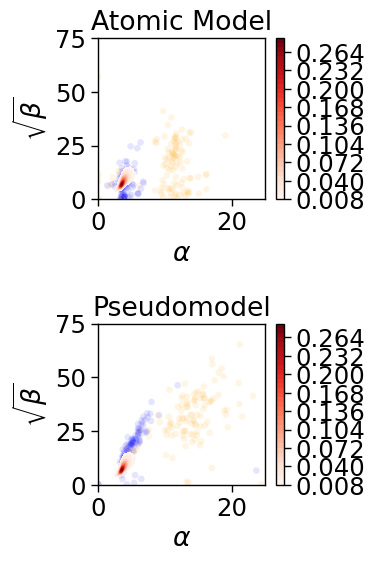

In [20]:
from matplotlib import ticker

palette = {"first" : "blue", "second": "orange"}
fig, ax = plt.subplots(2, 1, figsize=(4, 6))
y_max = 75 # max(max(alphas.max() * 3, sqrt_betas.max()) + 3, 45)
x_max = y_max // 3

sns.scatterplot(data=alpha_beta_data_long[alpha_beta_data_long["model"] == "atomic_model"], 
                x="alpha", y="sqrt_beta", hue="mode", ax=ax[0], palette=palette, alpha=0.1, legend=False)

ax[0].set_title("Atomic Model")
ax[0].set_xlim([0, x_max])
ax[0].set_ylim([0, y_max])
ax[0].set_xlabel("$\\alpha$")
ax[0].set_ylabel("$\\sqrt{\\beta}$")
N = 30
locator = ticker.MaxNLocator(N + 1, min_n_ticks=N)
lev = locator.tick_values(kde.min(), kde.max())
cfset = ax[0].contourf(xx, yy, kde, cmap='Reds', levels=lev[1:])
fig.colorbar(cfset)

sns.scatterplot(data=alpha_beta_data_long[alpha_beta_data_long["model"] == "pseudomodel"],
                x="alpha", y="sqrt_beta", hue="mode", ax=ax[1], palette=palette, alpha=0.1, legend=False)
ax[1].set_title("Pseudomodel")
ax[1].set_xlim([0, x_max])
ax[1].set_ylim([0, y_max])
ax[1].set_xlabel("$\\alpha$")
ax[1].set_ylabel("$\\sqrt{\\beta}$")

cfset = ax[1].contourf(xx, yy, kde, cmap='Reds', levels=lev[1:])
fig.colorbar(cfset)

fig.tight_layout()